In [1]:
import numpy as np
from mp_api.client import MPRester
from pymatgen.core.operations import SymmOp
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter
from jupyter_jsmol.pymatgen import quick_view
from lmapr1492 import plot_brillouin_zone, get_plot_bs, get_plot_dos, get_plot_bs_and_dos, get_branch_wavevectors
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
mp_key = "txVH20lqfEIM4Yxb2k5ptbih3BpgcIsN"
mp_id = "mp-1008680"

In [3]:
with MPRester(mp_key) as m:
    prim_struc = m.get_structure_by_material_id(mp_id)
    el_bs = m.get_bandstructure_by_material_id(mp_id)
    el_dos = m.get_dos_by_material_id(mp_id)
    ph_bs = m.get_phonon_bandstructure_by_material_id(mp_id)
    ph_dos = m.get_phonon_dos_by_material_id(mp_id)
conv_struc = SpacegroupAnalyzer(prim_struc).get_conventional_standard_structure()
symmops = SpacegroupAnalyzer(conv_struc).get_space_group_operations()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving PhononBSDOSDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving PhononBSDOSDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

# Phonon bandstructure

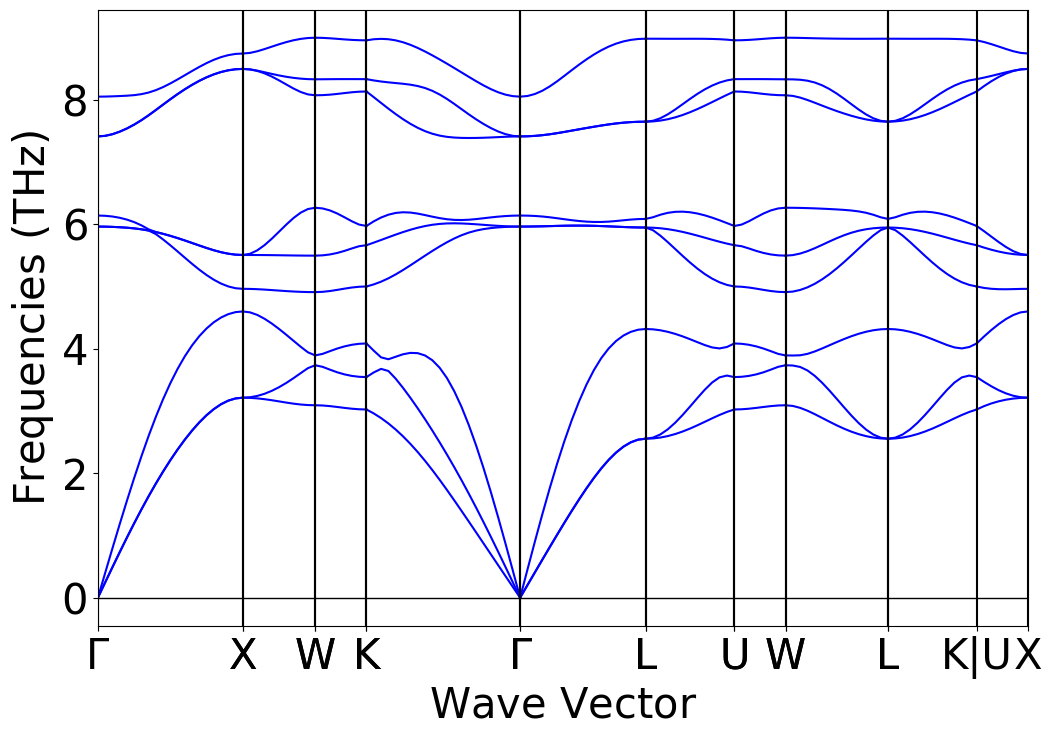

In [4]:
fig_ph_bs = PhononBSPlotter(ph_bs)
fig_ph_bs.show()

In [5]:
branches = ph_bs.branches


sound_velocities = []

for branch_id, branch in enumerate(branches):
    
    if branch_id < 3:
        
        wave_vectors = branch.get("q", [])
        frequencies = branch.get("frequency", [])
        
        
        if wave_vectors and frequencies:
            
            group_velocity = np.gradient(frequencies) / np.gradient(wave_vectors)
            
            sound_velocity = np.max(np.abs(group_velocity))
            
            sound_velocities.append(sound_velocity)
            
        

In [7]:
print("Sound velocities for three branches and directions:")
for idx, velocity in enumerate(sound_velocities):
    print(f"Branch {id + 1}: {velocity:.2f} m/s")


Sound velocities for three branches and directions:


Il semblerait que mon code compile mais que rien n'en sort, je ne comprends pas l'erreur.
